In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
from datasets import load_dataset
from torchvision.transforms import v2
import dotenv
import os
import utils.cifar10_classification

In [3]:
dotenv.load_dotenv()
#print(os.getenv("HF_TOKEN")) #HF_TOKEN prescence in envvars is automatically detected by huggingface functions

True

In [4]:
import os
import ssl
import torch
from torch.utils.data import Dataset, random_split
from torchvision.datasets import MNIST as TorchMNIST
from torchvision.transforms import v2

# 1. Programmatically bypass your local SSL certificate verification error
ssl._create_default_https_context = ssl._create_unverified_context

# 2. Updated Transforms for MNIST
# We add Grayscale(3) and Resize(32) so this dataset acts exactly like CIFAR-10
train_transform = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=3),  # Converts 1-channel MNIST to 3-channel pseudo-RGB
    v2.Resize((32, 32)),                  # Upscales from 28x28 to your original 32x32 size
    v2.RandomCrop(32, padding=4), 
    v2.RandomHorizontalFlip(p=0.5), 
    v2.ToDtype(torch.float32, scale=True),
    # Adjusted mean/std vectors to match 3 channels instead of 1
    v2.Normalize(mean=[0.1307, 0.1307, 0.1307], std=[0.3081, 0.3081, 0.3081]) 
])

eval_transform = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=3),
    v2.Resize((32, 32)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307, 0.1307, 0.1307], std=[0.3081, 0.3081, 0.3081])
])

# 3. Download and load via Torchvision (Fast ~11MB download total)
full_train_raw = TorchMNIST(root='./data', train=True, download=True)
full_test_raw = TorchMNIST(root='./data', train=False, download=True)

# 4. Slice the raw data to match your percentages (5% train, 2% test)
train_size = int(0.05 * len(full_train_raw))   # 5% of 60,000 = 3,000
test_size = int(0.02 * len(full_test_raw))     # 2% of 10,000 = 200

train_subset, _ = random_split(full_train_raw, [train_size, len(full_train_raw) - train_size])
test_subset, _ = random_split(full_test_raw, [test_size, len(full_test_raw) - test_size])

class MNISTWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # PyTorch MNIST returns a tuple of (PIL.Image, int_label)
        img, label = self.subset[idx] 
        img = self.transform(img)
        return img, label

dataset_train = MNISTWrapper(train_subset, train_transform)
print(f"Training dataset size: {len(dataset_train)}") # Outputs 3000

val_size = len(test_subset) // 2
test_slice_1, test_slice_2 = random_split(test_subset, [val_size, len(test_subset) - val_size])

dataset_val = MNISTWrapper(test_slice_1, eval_transform)
dataset_test = MNISTWrapper(test_slice_2, eval_transform)

print(f"Validation dataset size: {len(dataset_val)}") # Outputs 100
print(f"Testing dataset size: {len(dataset_test)}")   # Outputs 100


Training dataset size: 3000
Validation dataset size: 100
Testing dataset size: 100


In [5]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=64, shuffle=True)

In [6]:
import architectures.BasicNet

In [7]:
BasicNet = architectures.BasicNet.BasicNet()

In [ ]:
bn = BasicNet()
utils.cifar10_classification.train(bn,train_loader, val_loader)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


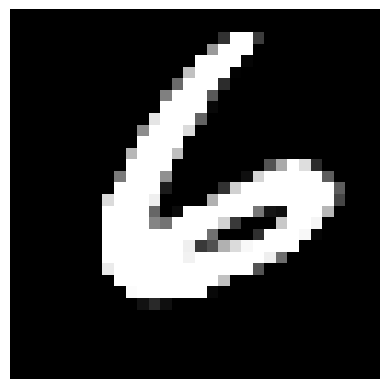

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.7960305].


Predicted Class: 6


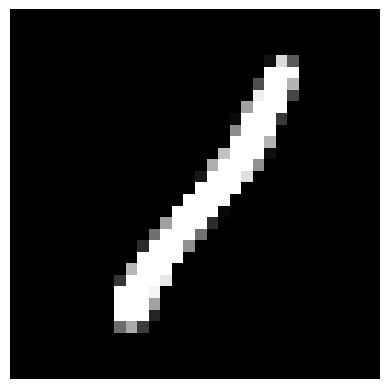

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


Predicted Class: 8


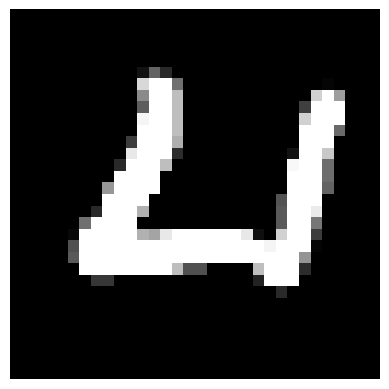

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


Predicted Class: 0


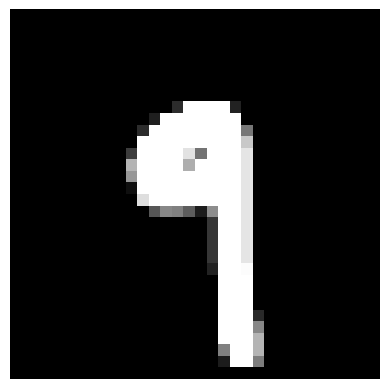

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.7960305].


Predicted Class: 3


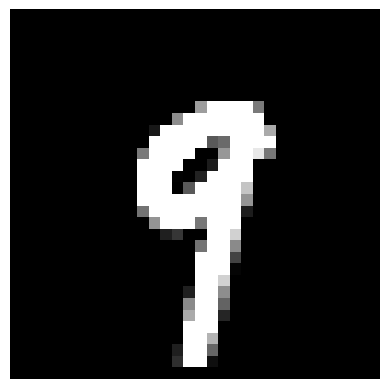

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


Predicted Class: 8


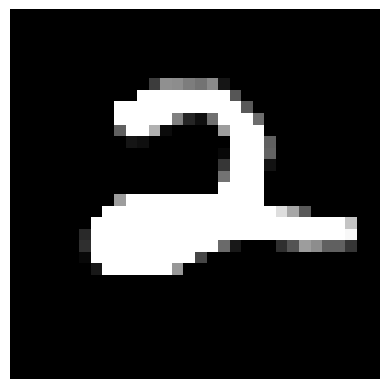

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


Predicted Class: 9


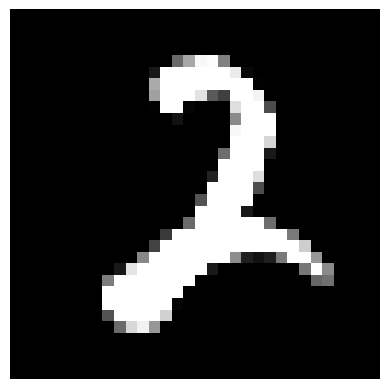

Predicted Class: 9


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.7960305].


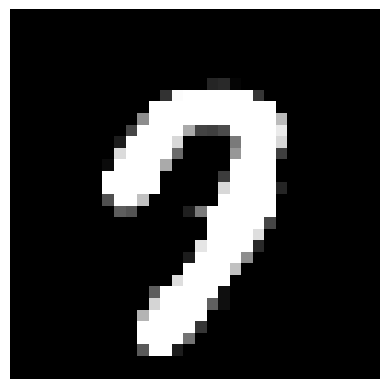

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.7323892].


Predicted Class: 8


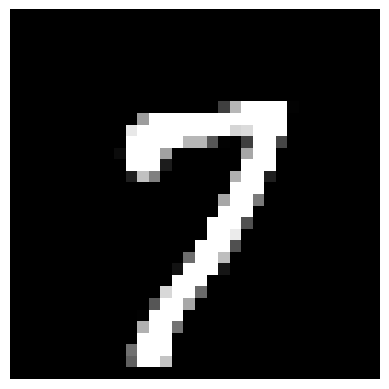

Predicted Class: 3


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.783302].


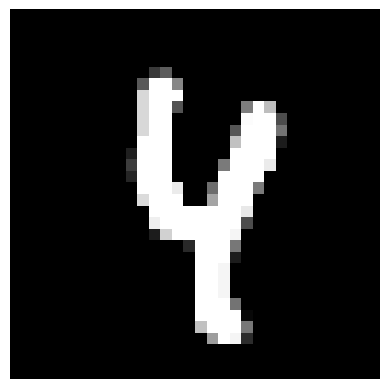

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


Predicted Class: 9


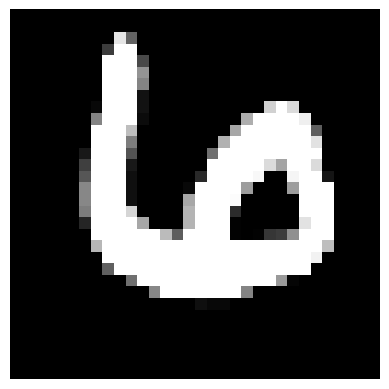

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


Predicted Class: 8


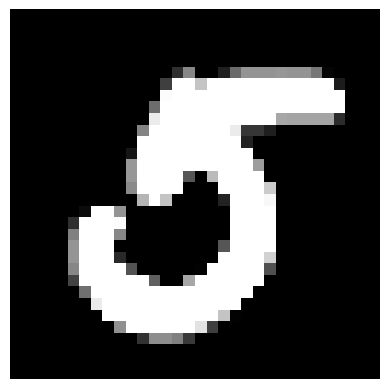

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.7960305].


Predicted Class: 0


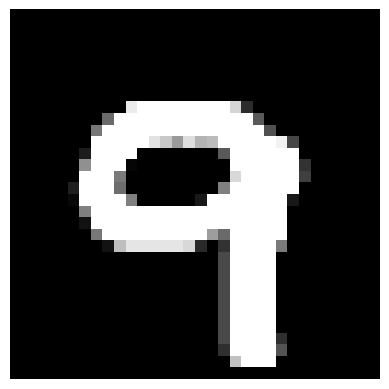

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


Predicted Class: 2


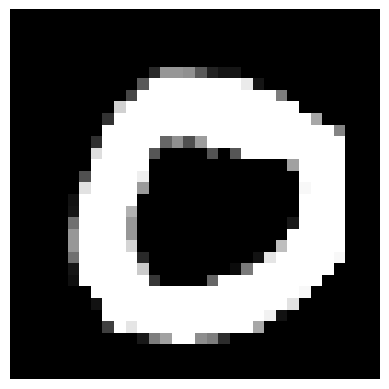

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


Predicted Class: 0


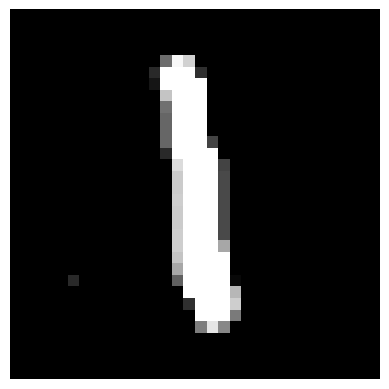

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


Predicted Class: 1


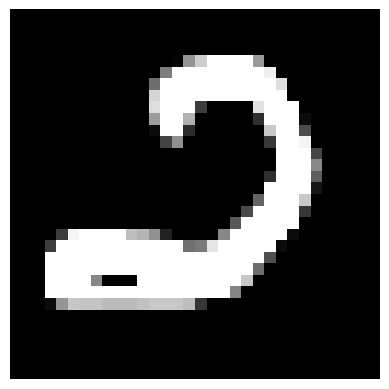

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


Predicted Class: 0


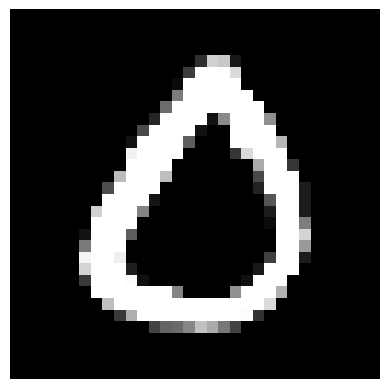

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.7960305].


Predicted Class: 2


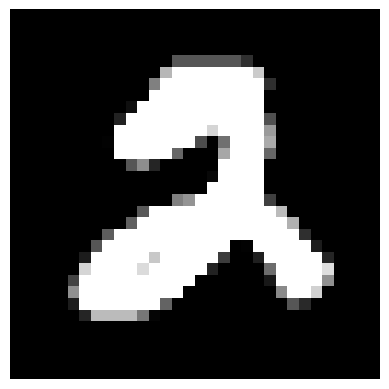

Predicted Class: 8


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


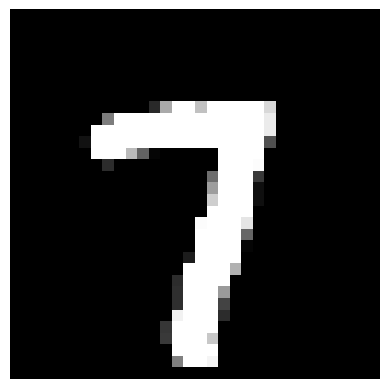

Predicted Class: 2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


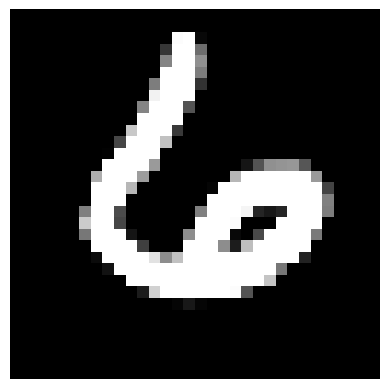

Predicted Class: 6


In [ ]:
utils.cifar10_classification.test(bn,test_loader)